In [ ]:
import sys

sys.path.append('..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from omegaconf import OmegaConf
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
from torchvision import transforms

from virtuesm2.models.virtuesm2_hf import VirTuesM2_HF
from virtuesm2.utils.utils import load_marker_embedding_dict

### Inference Example

This notebook demonstrates how to load VirTues-M2, load the images and how to pass the data to VirTues-M2.

Furthermore, we show how both uni-modal and multi-modal inference with VirTues-M2 is performed and show PCAs for the modality-wise patch tokens.

#### Load the multiplex and H&E sample crop

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

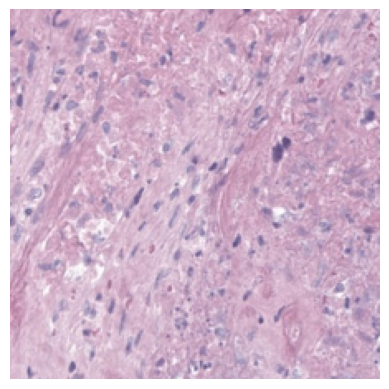

In [2]:
mx_image_raw = np.load("../example_data/mx_example_crop_1.npy")
mx_image_raw = torch.tensor(mx_image_raw)
he_image_raw = np.array(Image.open("../example_data/he_example_crop_1.png").convert("RGB"))
he_image_raw = torch.tensor(he_image_raw)
plt.imshow(he_image_raw)
plt.axis("off")

#### Load ESM-2 embeddings

In [3]:
esm_embeddings = load_marker_embedding_dict("../example_data/esm_embeddings")

# esm embeddings for channels
marker_names = pd.read_csv("../example_data/gene_dict.csv")

In [4]:
mx_image = mx_image_raw[marker_names["protein_id"].values != "Exclude"]
uniprot_ids = marker_names["protein_id"].values[marker_names["protein_id"].values != "Exclude"]
uniprot_indices = torch.tensor([esm_embeddings[uniprot_id] for uniprot_id in uniprot_ids]).unsqueeze(0)

#### Apply Normalization

In [5]:
mean_he = [0.7068, 0.5755, 0.722]
std_he = [0.195, 0.2316, 0.1816]
he_normalization = transforms.Normalize(mean=mean_he, std=std_he)

# Q99 normalization
clip_values = pd.read_csv("../example_data/q99.csv")
valid_markers = marker_names["name"].values[marker_names["protein_id"].values != "Exclude"]
clip_values = torch.tensor(clip_values[valid_markers].values[0])

In [6]:
he_image = he_normalization(he_image_raw.permute(2,0,1)/255.0)
mx_image = torch.clamp(mx_image, min=torch.zeros_like(mx_image), max=clip_values.view(-1,1,1)) / clip_values.view(-1,1,1)
mx_image = mx_image.half()

#### Create Model

In [8]:
marker_embedding_dir = "../example_data/esm_embeddings"
model = VirTuesM2_HF.from_pretrained("bunnelab/virtues-m2", marker_embedding_dir=marker_embedding_dir, force_download=True)

#### Forward pass through model

In [9]:
model.cuda()
model.eval()

with torch.inference_mode():
    with torch.amp.autocast("cuda", dtype=torch.float16):
        mx_image = mx_image.cuda()
        he_image = he_image.cuda()

        mm_embeddings = model.forward_features(mx_image.unsqueeze(0), he_image.unsqueeze(0), uniprot_indices)
        he_embeddings = model.forward_features([None], he_image.unsqueeze(0), [None])
        mx_embeddings = model.forward_features(mx_image.unsqueeze(0), [None], uniprot_indices)

In [10]:
mm_cls = mm_embeddings["x_norm_clstoken"]
mm_patchtokens_mx = mm_embeddings["x_norm_patchtokens_multiplex"]
mm_patchtokens_he = mm_embeddings["x_norm_patchtokens_he"]

Now, the CLS token (mm_cls) contains the multi-modal global information of the crop, whereas the per-modality patch tokens contain the local information for each modality which has been informed by the respective other modality during the forward pass through VirTues-M2. 

#### Plot PCAs of the crop

In [11]:
def calc_pca(embeddings):
    pca = PCA(n_components=3)
    fg_patches = np.vstack(embeddings)
    pca_features = pca.fit_transform(fg_patches)
    fg_result = minmax_scale(pca_features)
    return fg_result

In [12]:
mx_tokens = mm_patchtokens_mx.cpu().numpy()[0]
he_tokens = mm_patchtokens_he.cpu().numpy()[0]

mx_pca = calc_pca(mx_tokens).reshape(16, 16, -1)
he_pca = calc_pca(he_tokens).reshape(16, 16, -1)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

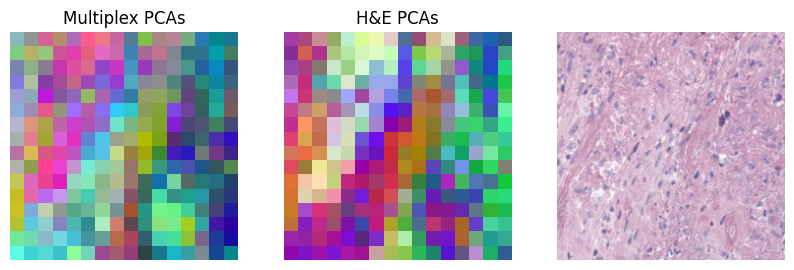

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(10, 6))
axs[0].set_title("Multiplex PCAs")
axs[0].imshow(mx_pca)
axs[0].axis("off")
axs[1].set_title("H&E PCAs")
axs[1].imshow(he_pca)
axs[1].axis("off")
axs[2].imshow(he_image_raw)
axs[2].axis("off")

If we want higher resolution PCAs, we can scale up the image before the forward pass

In [14]:
from skimage.transform import resize

In [15]:
resize_factor = 3

mx_image_resized = resize(mx_image.cpu().numpy(), (mx_image.shape[0], int(224 * resize_factor), int(224 * resize_factor)), preserve_range=True)
mx_image_resized = torch.tensor(mx_image_resized).cuda().half()
he_image_resized = resize(he_image.cpu().numpy(), (he_image.shape[0], int(224 * resize_factor), int(224 * resize_factor)), preserve_range=True)
he_image_resized = torch.tensor(he_image_resized).cuda()
with torch.inference_mode():
    with torch.amp.autocast("cuda", dtype=torch.float16):
        mm_embeddings_resized = model.forward_features(mx_image_resized.unsqueeze(0), he_image_resized.unsqueeze(0), uniprot_indices)
        mx_embeddings_resized = model.forward_features(mx_image_resized.unsqueeze(0), [None], uniprot_indices)

In [16]:
# Multi-modal embeddings
mm_patchtokens_mx = mm_embeddings_resized["x_norm_patchtokens_multiplex"]
mm_patchtokens_he = mm_embeddings_resized["x_norm_patchtokens_he"]
mx_tokens = mm_patchtokens_mx.cpu().numpy()[0]
he_tokens = mm_patchtokens_he.cpu().numpy()[0]

mm_mx_pca = calc_pca(mx_tokens).reshape(int(16 * resize_factor), int(16 * resize_factor), -1)
mm_he_pca = calc_pca(he_tokens).reshape(int(16 * resize_factor), int(16 * resize_factor), -1)

# MX-based embeddings (Note, we also get H&E-wise embeddings - a prediction of the model how the H&E tokens would look like)
mx_patchtokens_mx = mx_embeddings_resized["x_norm_patchtokens_multiplex"]
mx_patchtokens_he = mx_embeddings_resized["x_norm_patchtokens_he"]
mx_tokens = mx_patchtokens_mx.cpu().numpy()[0]
he_tokens = mx_patchtokens_he.cpu().numpy()[0]

mx_mx_pca = calc_pca(mx_tokens).reshape(int(16 * resize_factor), int(16 * resize_factor), -1)
mx_he_pca = calc_pca(he_tokens).reshape(int(16 * resize_factor), int(16 * resize_factor), -1)

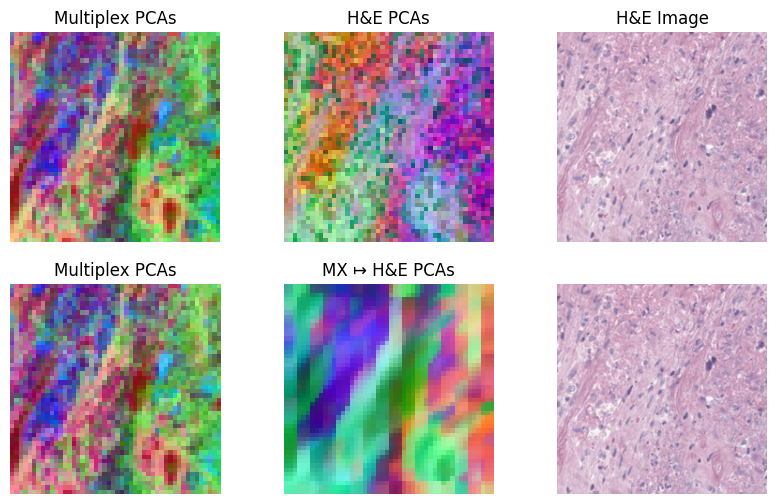

In [17]:
import seaborn as sns
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
axs = axs.flatten()
axs[0].set_title("Multiplex PCAs")
axs[0].imshow(mm_mx_pca)
axs[1].set_title("H&E PCAs")
axs[1].imshow(mm_he_pca)
axs[2].imshow(he_image_raw)
axs[2].set_title("H&E Image")
axs[3].set_title("Multiplex PCAs")
axs[3].imshow(mx_mx_pca)
axs[4].set_title("MX ↦ H&E PCAs")
axs[4].imshow(mx_he_pca)
axs[5].imshow(he_image_raw)

for ax in axs:
    ax.axis("off")

axs[0].set_xticks([])
axs[0].set_yticks([])
axs[3].set_xticks([])
axs[3].set_yticks([])
axs[0].set_ylabel("Multi-modal Input")
axs[3].set_ylabel("Multiplex Input")
sns.despine(ax=axs[0], bottom=True, left=True)
sns.despine(ax=axs[3], bottom=True, left=True)